# HR Attrition Analysis

**Dataset:** IBM HR Analytics Employee Attrition (1,470 employees, 35 columns)  
**Tools:** Python, pandas, SQLite3, matplotlib, seaborn  
**Goal:** Identify the key drivers of employee attrition to help HR teams reduce turnover  

---

## 1. Load Data

Upload the raw IBM HR Analytics CSV file from your local machine into Google Colab.

In [ ]:
from google.colab import files

uploading = files.upload()


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


## 2. Explore the Raw Dataset

The raw dataset contains **1,470 employees** and **35 columns**. We inspect the column names and first few rows to understand the structure.

In [ ]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape",df.shape)
print("\nColumns",df.columns)
df.head()

Shape (1470, 35)

Columns Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Select Relevant Columns

From the original 35 columns, we keep the **12 most analytically relevant features** for our attrition analysis — covering demographics, job details, compensation, and work conditions.

In [ ]:
# Keep only the 12 most important columns for our analysis

cols_needed = ['Age', 'Attrition', 'Department', 'DistanceFromHome',
    'Gender', 'JobRole', 'JobSatisfaction', 'MonthlyIncome',
    'OverTime', 'TotalWorkingYears', 'WorkLifeBalance',
    'YearsAtCompany']

df = df[cols_needed]
print("Shape",df.shape)
print("\nColumns",df.columns)
df.head()

Shape (1470, 12)

Columns Index(['Age', 'Attrition', 'Department', 'DistanceFromHome', 'Gender',
       'JobRole', 'JobSatisfaction', 'MonthlyIncome', 'OverTime',
       'TotalWorkingYears', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')


,Age,Attrition,Department,DistanceFromHome,Gender,JobRole,JobSatisfaction,MonthlyIncome,OverTime,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,Female,Sales Executive,4,5993,Yes,8,1,6
1,49,No,Research & Development,8,Male,Research Scientist,2,5130,No,10,3,10
2,37,Yes,Research & Development,2,Male,Laboratory Technician,3,2090,Yes,7,3,0
3,33,No,Research & Development,3,Female,Research Scientist,3,2909,Yes,8,3,8
4,27,No,Research & Development,2,Male,Laboratory Technician,2,3468,No,6,3,2


## 4. Data Quality Check

Check for missing values across all columns. **Result: No null values found** — the dataset is clean and ready for analysis.

In [ ]:
# checking null values

print("Null Values :\n")
print(df.isnull().sum())

Null Values :

Age                  0
Attrition            0
Department           0
DistanceFromHome     0
Gender               0
JobRole              0
JobSatisfaction      0
MonthlyIncome        0
OverTime             0
TotalWorkingYears    0
WorkLifeBalance      0
YearsAtCompany       0
dtype: int64


### Check Data Types

Verify that each column has the correct data type before encoding and analysis.

In [ ]:
# checking the data type

print("Data Types :\n")
print(df.dtypes)

Data Types :

Age                   int64
Attrition            object
Department           object
DistanceFromHome      int64
Gender               object
JobRole              object
JobSatisfaction       int64
MonthlyIncome         int64
OverTime             object
TotalWorkingYears     int64
WorkLifeBalance       int64
YearsAtCompany        int64
dtype: object


### Basic Statistics

Summary statistics for all numeric columns — useful for spotting outliers and understanding distributions.

In [ ]:
print("\nBasic Statistics :\n")
df.describe()


Basic Statistics :



,Age,DistanceFromHome,JobSatisfaction,MonthlyIncome,TotalWorkingYears,WorkLifeBalance,YearsAtCompany
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.728571,6502.931293,11.279592,2.761224,7.008163
std,9.135373,8.106864,1.102846,4707.956783,7.780782,0.706476,6.126525
min,18.000000,1.000000,1.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2.000000,2.000000,2911.000000,6.000000,2.000000,3.000000
50%,36.000000,7.000000,3.000000,4919.000000,10.000000,3.000000,5.000000
75%,43.000000,14.000000,4.000000,8379.000000,15.000000,3.000000,9.000000
max,60.000000,29.000000,4.000000,19999.000000,40.000000,4.000000,40.000000


## 5. Encode Categorical Columns

Convert `Attrition` (Yes/No) and `OverTime` (Yes/No) to binary values (1/0) so they can be used in SQL aggregations and later analysis.

In [ ]:
# Convert Attrition: Yes = 1, No = 0

df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print("Attrition values:",df['Attrition'].unique())
print("OverTime values:",df['OverTime'].unique())

Attrition values: [1 0]
OverTime values: [1 0]


## 6. Overall Attrition Rate

Calculate the headline metric — the percentage of employees who left the company.

> **Key Finding:** The overall attrition rate is **16.12%** (237 out of 1,470 employees).

In [ ]:
# Check Attrition Rate (Your First Insight)

total = len(df)
left = df['Attrition'].sum()
stayed = total - left
rate = round((left/total) * 100,2)

print(f"Total Employees: {total}")
print(f"Employees Left: {left} ")
print(f"Employees Stayed: {stayed}")
print(f"Attrition Rate: {rate}%")

Total Employees: 1470
Employees Left: 237 
Employees Stayed: 1233
Attrition Rate: 16.12%


## 7. Save Cleaned Dataset

Export the cleaned dataset as a CSV file for use in Power BI.

In [ ]:
# saving file

df.to_csv("hr_attrition_cleaned.csv",index=False)
print("File save successfully")

File save successfully


---

## 8. SQL Analysis

Load the cleaned data into an **SQLite3 in-memory database** and run SQL queries to calculate attrition rates across four key dimensions:

- Department
- Job Role
- Overtime Status
- Salary Band

### Create Database

In [ ]:
# import sql

import sqlite3

# Creating the database and load cleaned data

conn = sqlite3.connect('hr_attrition.db')
df.to_sql('hr_data',conn,if_exists='replace',index=False)
print("Database created successfully")

Database created successfully


### Query 1 — Attrition by Department

Which department has the highest attrition rate?

> **Key Finding:** Sales has the highest attrition at **20.63%**, followed by Human Resources at 19.05%.

In [ ]:
query1 = """
SELECT
Department,
COUNT(*) AS Total_Employees,
SUM(Attrition) AS Employees_Left,
ROUND(SUM(Attrition)* 100.0 / COUNT(*), 2) AS Attrition_Rate
FROM hr_data
GROUP BY Department
ORDER BY Attrition_rate DESC
"""
result1 = pd.read_sql_query(query1,conn)
print("Attrition by Department\n")
print(result1)

Attrition by Department

               Department  Total_Employees  Employees_Left  Attrition_Rate
0                   Sales              446              92           20.63
1         Human Resources               63              12           19.05
2  Research & Development              961             133           13.84


### Query 2 — Attrition by Job Role

Which job roles are at the highest risk of leaving?

> **Key Finding:** Sales Representatives have the highest attrition at **39.76%** — nearly 1 in 2 employees leave. Research Directors have the lowest at 2.50%.

In [ ]:
query2 = """
SELECT
JobRole,
COUNT(*) AS Total_Employees,
SUM(Attrition) AS Employees_Left,
ROUND(SUM(Attrition)* 100.0 / COUNT(*), 2) AS Attrition_Rate
FROM hr_data
GROUP BY JobRole
ORDER BY Attrition_Rate DESC
"""
result2 = pd.read_sql_query(query2,conn)
print("Attrition by Job Role:\n")
print(result2)

Attrition by Job Role:

                     JobRole  Total_Employees  Employees_Left  Attrition_Rate
0       Sales Representative               83              33           39.76
1      Laboratory Technician              259              62           23.94
2            Human Resources               52              12           23.08
3            Sales Executive              326              57           17.48
4         Research Scientist              292              47           16.10
5     Manufacturing Director              145              10            6.90
6  Healthcare Representative              131               9            6.87
7                    Manager              102               5            4.90
8          Research Director               80               2            2.50


### Query 3 — Impact of Overtime on Attrition

Does working overtime significantly increase the likelihood of an employee leaving?

> **Key Finding:** Overtime workers leave at **30.53%** — nearly **3x higher** than employees without overtime (10.44%). This is the strongest predictor of attrition in the dataset.

In [ ]:
query3 = """
SELECT
CASE WHEN OverTime = 1 THEN 'Yes' ELSE 'No' END AS OverTime,
COUNT(*) AS Total_Employees,
SUM(Attrition) AS Employees_Left,
ROUND(SUM(Attrition) * 100.0 / COUNT(*) , 2) AS Attrition_Rate
FROM hr_data
GROUP BY OverTime
ORDER BY Attrition_Rate DESC
"""

result3 = pd.read_sql_query(query3,conn)
print("Impact of OverTime:\n")
print(result3)

Impact of OverTime:

  OverTime  Total_Employees  Employees_Left  Attrition_Rate
0      Yes              416             127           30.53
1       No             1054             110           10.44


### Query 4 — Attrition by Salary Band

How does monthly income affect attrition? Employees are grouped into four salary bands.

> **Key Finding:** Employees earning below $3,000/month have a **28.61%** attrition rate. This drops sharply to just **8.90%** for employees earning above $10,000/month — confirming that compensation is a major driver of turnover.

In [ ]:
query4 = """
SELECT
CASE
WHEN MonthlyIncome < 3000 THEN 'Below 3k'
WHEN MonthlyIncome BETWEEN 3000 AND 6000 THEN '3k - 6k'
WHEN MonthlyIncome BETWEEN 6001 AND 10000 THEN '6k - 10k'
ELSE 'Above 10k'
END AS Salary_Band,
COUNT(*) AS Total_Employees,
SUM(Attrition) AS Employees_Left,
ROUND(SUM(Attrition) * 100.0/ COUNT(*), 2) AS Attrition_Rate
FROM hr_data
GROUP BY Salary_Band
ORDER BY Attrition_Rate DESC
"""
result4 = pd.read_sql_query(query4,conn)
print("Attrition by Salary Band:\n")
print(result4)

Attrition by Salary Band:

  Salary_Band  Total_Employees  Employees_Left  Attrition_Rate
0    Below 3k              395             113           28.61
1     3k - 6k              519              66           12.72
2    6k - 10k              275              33           12.00
3   Above 10k              281              25            8.90


---

## 9. Visualizations

Create four charts to visually communicate the SQL findings. Each chart is saved as a PNG file for inclusion in reports and presentations.

### Chart Setup

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Style

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10,5)

### Chart 1 — Attrition Rate by Department

/tmp/ipykernel_736/1261940643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result1,x='Department',y='Attrition_Rate',palette='Reds_d')


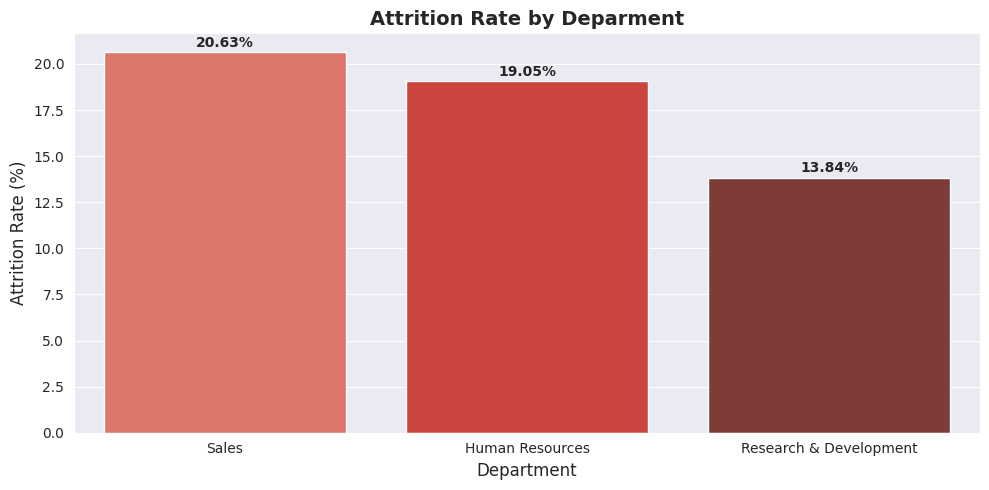

Chart 1 Saved!


In [ ]:
# Attrition by Department

plt.figure(figsize=(10,5))
sns.barplot(data=result1,x='Department',y='Attrition_Rate',palette='Reds_d')
plt.title('Attrition Rate by Deparment',fontsize=14,fontweight='bold')
plt.xlabel('Department',fontsize=12)
plt.ylabel('Attrition Rate (%)',fontsize=12)

# Add values labels on bars

for i,v in enumerate(result1['Attrition_Rate']):
  plt.text(i,v+ 0.3, f"{v}%",ha='center',fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_department.png',dpi=150)
plt.show()
print('Chart 1 Saved!')

### Chart 2 — Overtime Impact on Attrition

/tmp/ipykernel_736/3388123895.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result3,x='OverTime',y='Attrition_Rate',palette=['#2ecc71','#e74c3c'])


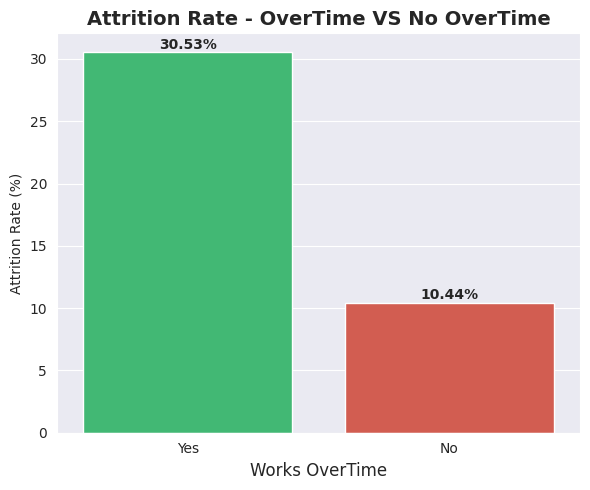

CHart 2 Saved!


In [ ]:
# Overtime Impact

plt.figure(figsize=(6,5))
sns.barplot(data=result3,x='OverTime',y='Attrition_Rate',palette=['#2ecc71','#e74c3c'])
plt.title('Attrition Rate - OverTime VS No OverTime',fontsize=14,fontweight='bold')
plt.xlabel('OverTime',fontsize=12)
plt.xlabel('Works OverTime')
plt.ylabel('Attrition Rate (%)')

for i,v in enumerate(result3['Attrition_Rate']):
  plt.text(i, v + 0.3, f'{v}%',ha='center',fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_overtime.png',dpi=150)
plt.show()
print('CHart 2 Saved!')

### Chart 3 — Attrition Rate by Salary Band

/tmp/ipykernel_736/3560016725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result4,x='Salary_Band',y='Attrition_Rate',


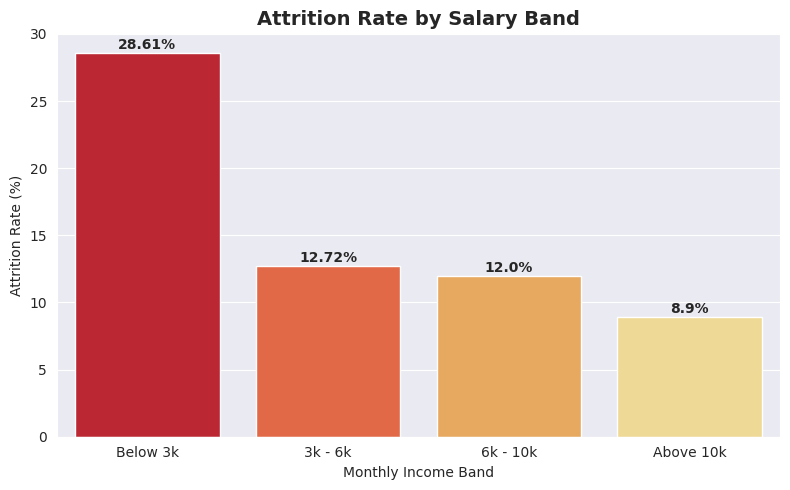

Chart 3 Saved!


In [ ]:
# Salary Band Attrition

plt.figure(figsize=(8,5))
Salary_order = ['Below 3k','3k - 6k','6k - 10k','Above 10k']
sns.barplot(data=result4,x='Salary_Band',y='Attrition_Rate',
            order=Salary_order,palette='YlOrRd_r')
plt.title('Attrition Rate by Salary Band',fontsize=14,fontweight='bold')
plt.xlabel('Monthly Income Band')
plt.ylabel('Attrition Rate (%)')

for i,v in enumerate(result4['Attrition_Rate']):
  plt.text(i, v + 0.3,f'{v}%',ha= 'center',fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_salary.png',dpi=150)
plt.show()
print('Chart 3 Saved!')

### Chart 4 — Top Job Roles by Attrition Rate

/tmp/ipykernel_736/1979879663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result2,x='Attrition_Rate',y='JobRole',palette='Blues_d')


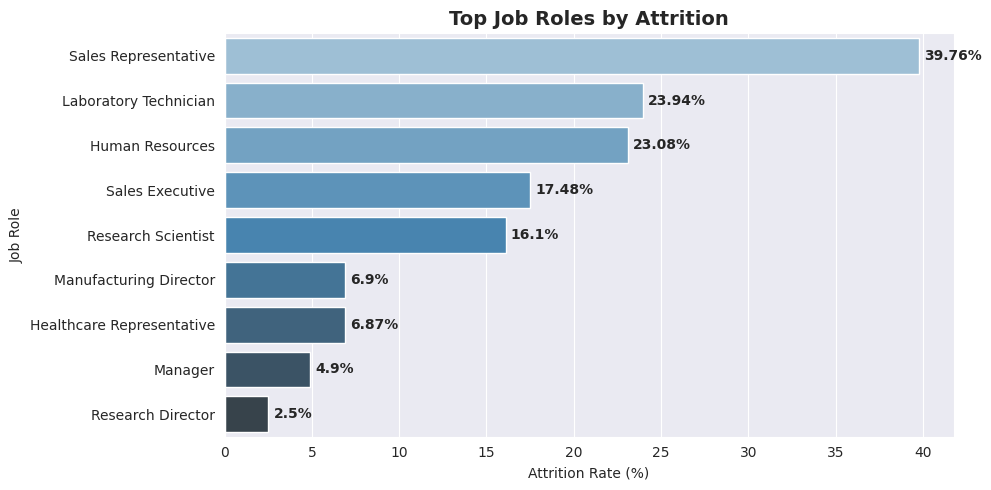

Chart 4 Saved!


In [ ]:
#  Top Job Roles by Attrition

plt.figure(figsize=(10,5))
sns.barplot(data=result2,x='Attrition_Rate',y='JobRole',palette='Blues_d')
plt.title('Top Job Roles by Attrition',fontsize=14,fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

for i,v in enumerate(result2['Attrition_Rate']):
  plt.text(v + 0.3,i,f'{v}%',va='center',fontweight='bold')

plt.tight_layout()
plt.savefig('chart4_jobrole.png',dpi=150)
plt.show()
print('Chart 4 Saved!')

---

## 10. Export Data for Power BI

Save all four SQL result tables as separate CSV files. These are loaded into **Power BI Desktop** to build the interactive dashboard.

In [ ]:
# Save all SQL results as CSV files for Power BI

result1.to_csv('dept_attrition.csv',index=False)
result2.to_csv('role_attrition.csv',index=False)
result3.to_csv('overtime_attrition.csv',index=False)
result4.to_csv('salary_attrition.csv',index=False)

print('All Files Saved!')

All Files Saved!


### Download Files to Local Machine

In [ ]:
#  Download All Files to Your Laptop

from google.colab import files

files.download('hr_attrition_cleaned.csv')
files.download('dept_attrition.csv')
files.download('role_attrition.csv')
files.download('overtime_attrition.csv')
files.download('salary_attrition.csv')

print('All downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded!


---

## Summary of Key Findings

| Finding | Value |
|---|---|
| Overall attrition rate | **16.12%** (237 / 1,470 employees) |
| Highest risk department | **Sales** — 20.63% |
| Highest risk job role | **Sales Representative** — 39.76% |
| Overtime attrition rate | **30.53%** (vs 10.44% without overtime) |
| Lowest salary band attrition | **Below $3k/month** — 28.61% |
| Highest salary band attrition | **Above $10k/month** — 8.90% |

---

## Next Steps

The cleaned CSV files generated above are loaded into **Power BI Desktop** to build an interactive HR Attrition Dashboard with KPI cards, bar charts, a donut chart, and interactive slicers for Department, Gender, and OverTime filters.

*View the full dashboard: [HR_Attrition_Dashboard.pbix](./HR_Attrition_Dashboard.pbix)*